In [1]:
# ── Cell 1: Setup ────────────────────────────────────────────────
import sys, os
from pathlib import Path
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mount Drive to get checkpoints
from google.colab import drive
drive.mount('/content/drive')

# Clone repo
from google.colab import userdata
!git config --global user.email "sivajithajithkumar777@gmail.com"
!git config --global user.name "sivrox"
# Clone your repo — replace with your actual URL
!git clone https://github.com/sivrox/Arabic-English-Sentiment-Analysis-Project.git
# Move into the folder
%cd Arabic-English-Sentiment-Analysis-Project

# Verify files are there
!ls

!pip install -q transformers scikit-learn seaborn
print("Setup done")

Mounted at /content/drive
Cloning into 'Arabic-English-Sentiment-Analysis-Project'...
remote: Enumerating objects: 187, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 187 (delta 30), reused 35 (delta 15), pack-reused 125 (from 1)
Receiving objects: 100% (187/187), 46.08 MiB | 28.82 MiB/s, done.
Resolving deltas: 100% (50/50), done.
Updating files: 100% (74/74), done.
/content/Arabic-English-Sentiment-Analysis-Project
configs     initial-files  peft_implementation.py  results_comparison.csv
deployment  models	   preprocessing	   session.tw_session
evaluation  notebooks	   README.md
Setup done


In [2]:
# ── Cell 2: Load best model (MARBERT Full FT) ─────────────────────
from transformers import AutoModelForSequenceClassification, AutoTokenizer

CHECKPOINT_PATH = '/content/drive/MyDrive/arabic-english-sentiment-analysis-trained-models/best_marbert_fft'
# ↑ adjust to your actual Drive folder name

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nLoading MARBERT Full FT checkpoint...")
model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT_PATH).to(DEVICE)
tokenizer = AutoTokenizer.from_pretrained('UBC-NLP/MARBERTv2')
model.eval()
print("Model loaded")


Loading MARBERT Full FT checkpoint...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model loaded


In [4]:
# ── Cell 3: Load code-switched samples ───────────────────────────
ROOT = Path('.')
cleaned_path = ROOT / 'preprocessing' / 'datasets' / 'processed' / 'cleaned_dataset.csv'
df = pd.read_csv(cleaned_path)

LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL = {0: 'negative', 1: 'neutral', 2: 'positive'}

# Get code-switched test samples with reliable labels
cs_df = df[
    (df['text_type'] == 'code_switched') &
    (df['split'] == 'test') &
    (df['label'].isin(['positive', 'negative', 'neutral']))
].copy()

cs_df['label_id'] = cs_df['label'].map(LABEL2ID)
cs_df = cs_df[cs_df['label_id'].notna()].copy()
cs_df['label_id'] = cs_df['label_id'].astype(int)

print(f"Code-switched test samples: {len(cs_df)}")
print(cs_df['label'].value_counts())

cs_texts = cs_df['cleaned_text'].tolist()[:300]
cs_labels = cs_df['label_id'].tolist()[:300]

Code-switched test samples: 26809
label
neutral     23949
positive     1618
negative     1242
Name: count, dtype: int64


In [8]:
# ── Cell 4: CSS Computation ───────────────────────────────────────
# CSS = Code-Switch Sensitivity Score
# Measures whether the model actually reads Arabic tokens
# or ignores them and only reads English

# Get Arabic token IDs from MARBERT vocabulary
vocab = tokenizer.get_vocab()
ARABIC_IDS = {
    tid for token, tid in vocab.items()
    if any('\u0600' <= c <= '\u06ff' for c in token)
}
print(f"Arabic token IDs in vocabulary: {len(ARABIC_IDS):,}")

PAD_ID = tokenizer.pad_token_id or 0

deltas, rows = [], []
n_no_arabic, n_wrong, n_low_conf = 0, 0, 0
THRESHOLD = 0.80
N_SAMPLES = 500

print(f"\nComputing CSS on {N_SAMPLES} samples...")
model.eval()

for i in range(min(N_SAMPLES, len(cs_texts))):
    enc = tokenizer(
        cs_texts[i], padding=True, truncation=True,
        max_length=128, return_tensors='pt'
    )
    ids = enc['input_ids'].to(DEVICE)
    attn = enc['attention_mask'].to(DEVICE)

    # Check if text has Arabic tokens
    has_arabic = any(t.item() in ARABIC_IDS for t in ids[0])
    if not has_arabic:
        n_no_arabic += 1
        continue

    with torch.no_grad():
        out = model(input_ids=ids, attention_mask=attn)
        probs = torch.softmax(out.logits, dim=-1)[0]
        pred = probs.argmax().item()
        conf = probs[pred].item()

    # Skip if wrong prediction
    if pred != cs_labels[i]:
        n_wrong += 1
        continue

    # Skip if low confidence
    if conf < THRESHOLD:
        n_low_conf += 1
        continue

    # Mask Arabic tokens and re-run
    masked_ids = ids.clone()
    for j in range(masked_ids.shape[1]):
        if masked_ids[0, j].item() in ARABIC_IDS:
            masked_ids[0, j] = PAD_ID

    with torch.no_grad():
        out_m  = model(input_ids=masked_ids, attention_mask=attn)
        probs_m = torch.softmax(out_m.logits, dim=-1)[0]
        conf_m  = probs_m[pred].item()

    delta = conf - conf_m
    deltas.append(delta)
    rows.append({
        'text' : cs_texts[i][:70],
        'true_label' : ID2LABEL[cs_labels[i]],
        'original_confidence' : round(conf, 4),
        'masked_confidence' : round(conf_m, 4),
        'delta' : round(delta, 4),
    })

css_score = float(np.mean(deltas)) if deltas else 0.0

if css_score > 0.25: interpretation = "Strong Arabic engagement — model genuinely reads Arabic"
elif css_score > 0.10: interpretation = "Moderate Arabic engagement"
else: interpretation = "Weak — model largely ignoring Arabic"

print(f"CSS Evaluation Results:")
print(f"\nCSS Score : {css_score:.4f}")
print(f"Interpretation : {interpretation}")
print(f"Samples used : {len(deltas)}")
print(f"Skipped (no Arabic tokens) : {n_no_arabic}")
print(f"Skipped (wrong prediction) : {n_wrong}")
print(f"Skipped (low confidence) : {n_low_conf}")

# Show most Arabic-reliant samples
css_df = pd.DataFrame(rows)
print(f"\nTop 5 — model relied MOST on Arabic:")
print(css_df.nlargest(5, 'delta')[['text','true_label','original_confidence','masked_confidence','delta']].to_string(index=False))

print(f"\nBottom 5 — model relied LEAST on Arabic:")
print(css_df.nsmallest(5, 'delta')[['text','true_label','original_confidence','masked_confidence','delta']].to_string(index=False))

Arabic token IDs in vocabulary: 91,359

Computing CSS on 500 samples...
CSS Evaluation Results:

CSS Score : 0.6604
Interpretation : Strong Arabic engagement — model genuinely reads Arabic
Samples used : 282
Skipped (no Arabic tokens) : 0
Skipped (wrong prediction) : 15
Skipped (low confidence) : 3

Top 5 — model relied MOST on Arabic:
                                                                  text true_label  original_confidence  masked_confidence  delta
انا بتعلم حاجات كتير جدا، منها ان انا ازاي اعمل web applications، ازاي    neutral               0.9999             0.0002 0.9997
دايما يعني بيبقي في ال weekends قرايبغي لان والدي و والدتي مش قاعدين م    neutral               0.9999             0.0006 0.9993
طيب انتي بعد ال .. بعد المدرسه دخلتي جامعه، دخلتي major ايه؟ و امتي كن    neutral               0.9999             0.0006 0.9993
طيب و بعد كده ال education بقي career انتي دخلتي major ايه؟ و ليه دخلت    neutral               0.9999             0.0006 0.9993
فمره هي صحيت الصب

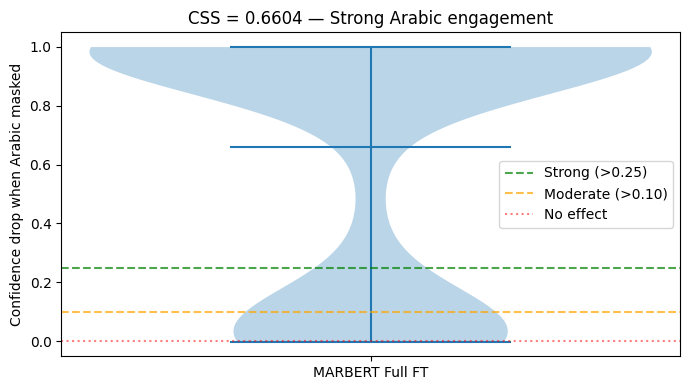

Saved: css_violin.png and css_results.json

Pushing results to GitHub:
git add css_violin.png css_results.json
git commit -m 'Add CSS cultural metric results'
git push origin main


In [9]:
# ── Cell 5: CSS Violin Plot ───────────────────────────────────────
import json

fig, ax = plt.subplots(figsize=(7, 4))
ax.violinplot([deltas], positions=[0], showmeans=True)
ax.axhline(y=0.25, color='green', linestyle='--', alpha=0.7, label='Strong (>0.25)')
ax.axhline(y=0.10, color='orange', linestyle='--', alpha=0.7, label='Moderate (>0.10)')
ax.axhline(y=0.0,  color='red', linestyle=':', alpha=0.5, label='No effect')
ax.set_xticks([0])
ax.set_xticklabels(['MARBERT Full FT'])
ax.set_ylabel('Confidence drop when Arabic masked')
ax.set_title(f'CSS = {css_score:.4f} — {interpretation.split("—")[0].strip()}')
ax.legend()
plt.tight_layout()
plt.savefig('css_violin.png', dpi=150)
plt.show()

# Save results to JSON for report
css_results = {
    'model' : 'MARBERT Full Fine-Tuning',
    'css_score' : round(css_score, 4),
    'interpretation' : interpretation,
    'n_samples_used' : len(deltas),
    'n_skipped_no_arabic': n_no_arabic,
    'n_skipped_wrong' : n_wrong,
    'n_skipped_low_conf' : n_low_conf,
}
with open('css_results.json', 'w') as f:
    json.dump(css_results, f, indent=2)

print("Saved: css_violin.png and css_results.json")
print("\nPushing results to GitHub:")
print("git add css_violin.png css_results.json")
print("git commit -m 'Add CSS cultural metric results'")
print("git push origin main")